<a href="https://colab.research.google.com/github/saraeastough/SCI1500-Sara-Eastough-public/blob/main/Copy_of_Week03_Lab_STUDENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 Lab: The Fishery Manager's Dilemma
**SCIE1500 — Analytical Methods for Scientists | Semester 2, 2026**

> **Lab format:** Work in your group. Discuss answers before typing code.
> **Today's session:** ~2 hours | Ask your tutor when stuck.

---
## 🌍 Scientific Scenario

![Schaefer growth curve with harvest lines and MSY point](https://github.com/ahailu95/scie1500-content/blob/main/SCIE1500Materials/Week_3/images/W3_fishery_schaefer.svg?raw=1)

You are a scientific advisor to the **Western Australian Fisheries Authority**. The authority manages a sardine fishery showing signs of overfishing.

Marine biologists use the **Schaefer model** for sardine population growth:

$$G(S) = g \cdot S \cdot \left(1 - \frac{S}{K}\right)$$

| Parameter | Value | Meaning |
|-----------|-------|---------|
| $g$ | 0.4 /yr | Intrinsic growth rate |
| $K$ | 1500 t | Carrying capacity |
| $S$ | 1200 t | Current stock |
| $H$ | 120 t/yr | Current harvest |

> *Is this harvest sustainable?*

---
## 🎯 Group Task & Learning Objectives

| Part | Time | You will be able to... |
|------|------|------|
| A | ~20 min | Use a Schaefer model to compute growth rates and Maximum Sustainable Yield (MSY), explaining bounded growth |
| B | ~25 min | Find equilibrium stock levels by solving a quadratic equation and interpret the stability of two equilibria for current and proposed harvest levels |
| C | ~10 min | Write a policy recommendation based on your analysis |

In [ ]:
# Run this cell first — loads libraries for today's lab
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

---
## Part A: The Schaefer Model (~20 min)

Expanding the Schaefer model:
$$G(S) = 0.4S\left(1 - \frac{S}{1500}\right) = 0.4S - \frac{0.4}{1500}S^2$$

This is a **downward-opening parabola** — growth is zero at $S = 0$ and $S = K$, and peaks at $S^* = K/2$.

In [ ]:
# A.1 — Define the Schaefer growth function and evaluate at three stock levels
g = 0.4      # intrinsic growth rate
K = 1500     # carrying capacity (tonnes)

def G(S):
    'Annual population growth (tonnes/year).'
    return g * S * (1 - S / K)

for S_level in [400, 750, 1200]:
    print(f"G({S_level:4d}) = {G(S_level):.1f} tonnes/year")

S_msy = K / 2
G_msy = G(S_msy)
print(f"\nMSY at S = K/2 = {S_msy:.0f} t  →  G_max = {G_msy:.1f} t/yr")

G( 400) = 117.3 tonnes/year
G( 750) = 150.0 tonnes/year
G(1200) = 96.0 tonnes/year

MSY at S = K/2 = 750 t  →  G_max = 150.0 t/yr


Plot the Schaefer growth curve.

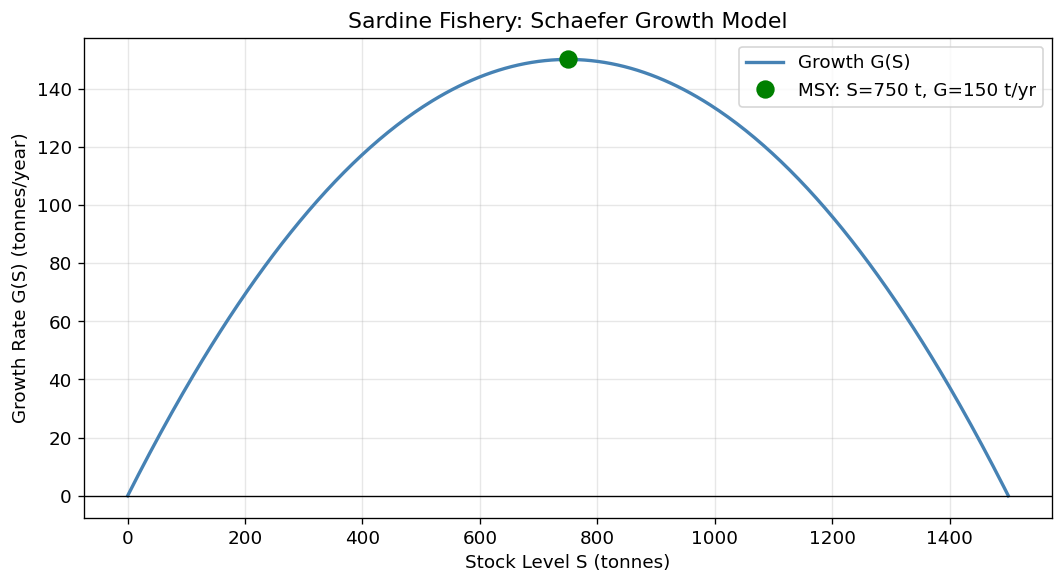

In [ ]:
# A.2 — Plot the Schaefer growth curve
S_vals = np.linspace(0, K, 400)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(S_vals, G(S_vals), "steelblue", lw=2, label="Growth G(S)")
ax.plot(S_msy, G_msy, "go", ms=10, label=f"MSY: S={S_msy:.0f} t, G={G_msy:.0f} t/yr")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("Stock Level S (tonnes)")
ax.set_ylabel("Growth Rate G(S) (tonnes/year)")
ax.set_title("Sardine Fishery: Schaefer Growth Model")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

✏️ **Activity A — discuss as a group:**
1. Why does growth peak at $S = K/2$ rather than near the maximum stock level?
2. What does $G(K) = 0$ represent ecologically?
3. At $S = 1200$ t (above $K/2$), is growth increasing or decreasing as stock rises?

```
Answers:
1. Carrying capacity of the environment. There are only so many resources the environment can cater for.
2. Nothing there.
3. Decreasing as stock rises.
```

---
## Part B: Sustainability Analysis (~25 min)

A harvest $H$ is **sustainable** when growth replaces what is removed: $G(S) \geq H$.

Setting $G(S) = H$ gives the **equilibrium stock levels** — states where stock stays constant.

Rearranging: $\frac{g}{K}S^2 - gS + H = 0$ → solve with the quadratic formula.

In [ ]:
# B.1 — Sustainability check at current stock
S_current = 1200
H = 120    # current harvest (tonnes/year)

G_current = G(S_current)
print(f"G(1200) = {G_current:.1f} t/yr")
print(f"H       = {H} t/yr")
print(f"Sustainable? {G_current >= H}  (need G >= H)")

G(1200) = 96.0 t/yr
H       = 120 t/yr
Sustainable? False  (need G >= H)


Equilibrium stock levels for H = 120: quadratic formula.

In [ ]:
# B.2 — Equilibrium stock levels for H = 120: quadratic formula
a_coef =  g / K
b_coef = -g
c_coef =  H

disc = b_coef**2 - 4 * a_coef * c_coef
S1 = (-b_coef - np.sqrt(disc)) / (2 * a_coef)   # lower (unstable)
S2 = (-b_coef + np.sqrt(disc)) / (2 * a_coef)   # upper (stable)

print(f"Equilibria for H = {H} t/yr:")
print(f"  S₁ = {S1:.1f} t  (lower — unstable collapse threshold)")
print(f"  S₂ = {S2:.1f} t  (upper — stable management target)")
print(f"  Current stock {S_current} t is {'above' if S_current > S1 else 'below'} collapse threshold.")

Equilibria for H = 120 t/yr:
  S₁ = 414.6 t  (lower — unstable collapse threshold)
  S₂ = 1085.4 t  (upper — stable management target)
  Current stock 1200 t is above collapse threshold.


What if harvest increases to 140 t/yr?

In [ ]:
# B.3 — What if harvest increases to 140 t/yr?
H_proposed = 140

c_new = H_proposed
disc_new = b_coef**2 - 4 * a_coef * c_new
if disc_new < 0:
    print(f"H = {H_proposed} t/yr exceeds MSY — no sustainable equilibrium!")
else:
    S1_new = (-b_coef - np.sqrt(disc_new)) / (2 * a_coef)
    S2_new = (-b_coef + np.sqrt(disc_new)) / (2 * a_coef)
    print(f"Equilibria for H = {H_proposed} t/yr:")
    print(f"  S₁ = {S1_new:.1f} t  (collapse threshold rises by {S1_new - S1:.1f} t → riskier)")
    print(f"  S₂ = {S2_new:.1f} t  (stable target falls by {S2 - S2_new:.1f} t → lower stock)")


Equilibria for H = 140 t/yr:
  S₁ = 556.4 t  (collapse threshold rises by 141.8 t → riskier)
  S₂ = 943.6 t  (stable target falls by 141.8 t → lower stock)


The chart below shows both scenarios.

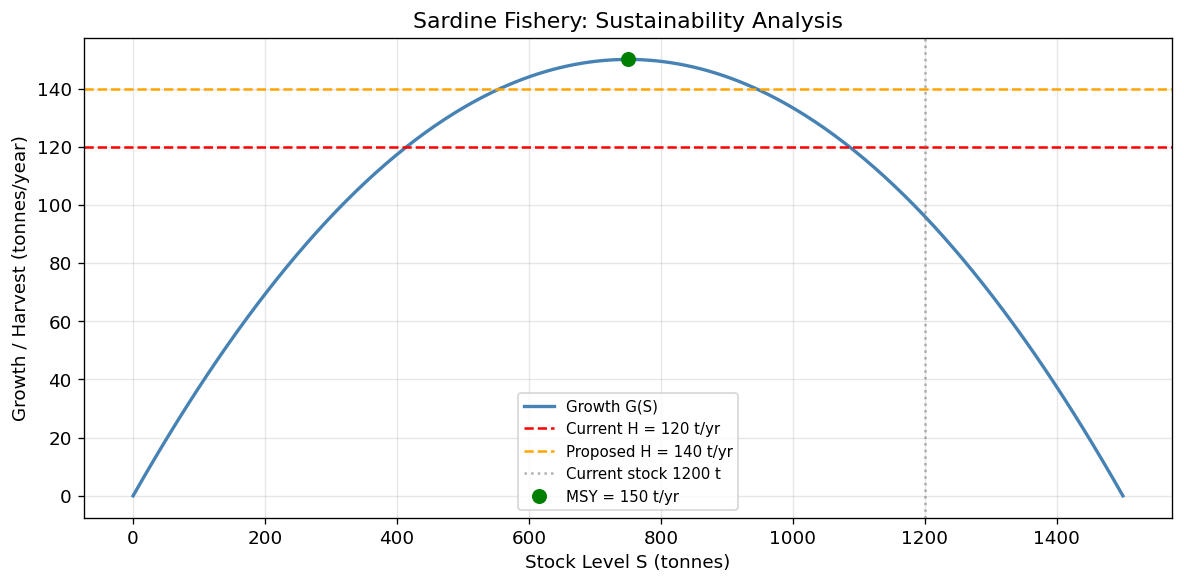

In [ ]:
# Plot both scenarios
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(S_vals, G(S_vals), "steelblue", lw=2, label="Growth G(S)")
ax.axhline(H,          color="red",    ls="--", lw=1.5, label=f"Current H = {H} t/yr")
ax.axhline(H_proposed, color="orange", ls="--", lw=1.5, label=f"Proposed H = {H_proposed} t/yr")
ax.axvline(S_current,  color="gray",   ls=":",  alpha=0.6, label=f"Current stock {S_current} t")
ax.plot(S_msy, G_msy, "go", ms=8, label=f"MSY = {G_msy:.0f} t/yr")
ax.set_xlabel("Stock Level S (tonnes)")
ax.set_ylabel("Growth / Harvest (tonnes/year)")
ax.set_title("Sardine Fishery: Sustainability Analysis")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

✏️ **Activity B:**
1. The current stock (1200 t) is *above* $S_2$ for $H = 120$. What happens to the stock over time?
2. Increasing harvest to 140 t/yr raises the collapse threshold. By how many tonnes?
3. The MSY is 150 t/yr. Why must harvest never exceed MSY?

```python
print("MSY =", G(K/2))
# Answers:
# 1. The stock will decrease
# 2. 141.8
# 3. That there will be no growth, the harvest will be too high.
```

---
## Part C: Policy Recommendation (~10 min)

Write a **4–5 sentence recommendation** to the Fisheries Authority:
- Is the current 120 t/yr harvest sustainable?
- Should the proposed 140 t/yr increase be approved?
- What harvest level do you recommend for long-term stability?

```
RECOMMENDATION TO WA FISHERIES AUTHORITY:

1. Is sustainable however, there is room to harvest more.
2. Yes.
3. 120t/yr would be better for in the case that something goes wrong to the external environment there is more wriggle room where the population growth won't be in as much danger.
```

---
## ✅ Lab Wrap-Up

- [ ] Computed $G(S)$ at three stock levels and identified the MSY (Part A)
- [ ] Found equilibrium stock levels for both harvest scenarios (Part B)
- [ ] Written a policy recommendation with specific numbers (Part C)
- [ ] **Groups 3 & 4:** Opened your Presentation Brief (Lab A or Lab B) and started Part A

> 💡 **Key insight:** There are always *two* equilibria — one stable (recovery target), one unstable (collapse threshold). Higher harvest brings these closer together.


---
---
## ✅ Submission Exercise — Batch 1

**Due: Monday 11 August, 11:59 pm — submit on LMS**
**Covers: Weeks 1–3 (functions, exponential models, logistic growth)**

Submit individually. Show full mathematical working for all calculations.
Upload your **completed notebook (.ipynb)** to the LMS — do not submit screenshots.
        

In [ ]:

# Fill in your details before submitting
student_name   = "Sara Eastough"
student_number = "25206803"
print(f"Submission by: {student_name}  |  Student #{student_number}")


Submission by: Sara Eastough  |  Student #25206803



---
### Q1 — Functions and Rates of Change (Week 1)

Southern bluefin tuna population data:

| Year | $t$ (yrs since 2000) | $P(t)$ (thousand fish) |
|------|---------------------|------------------------|
| 2000 | 0  | 90 |
| 2005 | 5  | 82 |
| 2010 | 10 | 71 |
| 2015 | 15 | 65 |
| 2020 | 20 | 61 |

**(a)** Calculate the average rate of change of $P$ over each of the four 5-year intervals. Show working.
        


**Answer (a):**

P(b)-P(a)/b-a
a=0
b=20
P(0)=90
P(20)=61

61-90/20-0 = -29/20 = -1.45 thousand fish/yr
        


**(b)** Is the decline rate constant? Describe the pattern and what it implies about the shape of $P(t)$.
        


**Answer (b):**

No. The decline rate gets steeper. The pattern will be a curved line.
        


**(c)** Plot $P(t)$ from $t = 0$ to $t = 20$. Does a linear model fit this data well? Explain.
        

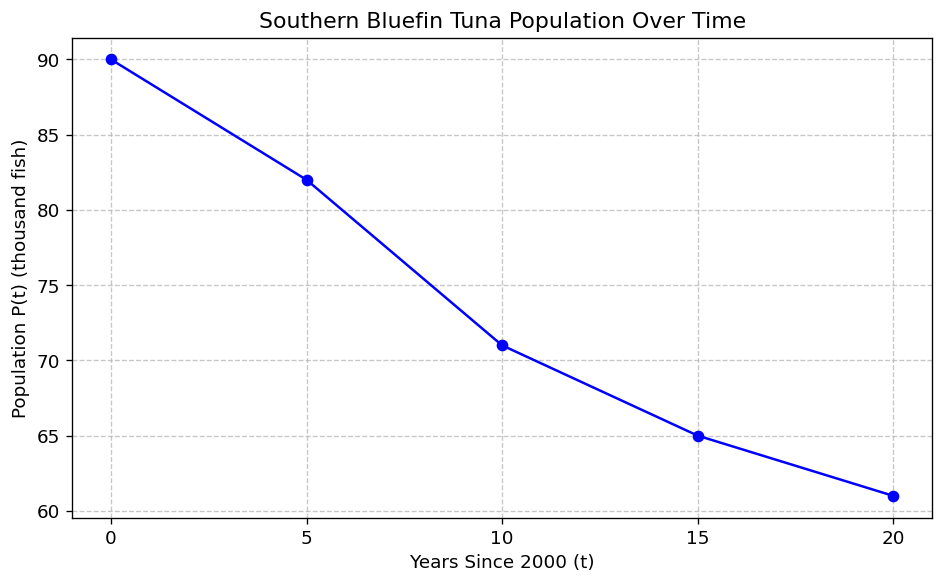

In [ ]:

t_values = np.array([0, 5, 10, 15, 20])
P_values = np.array([90, 82, 71, 65, 61])

plt.figure(figsize=(8, 5))
plt.plot(t_values, P_values, marker='o', linestyle='-', color='b')
plt.title('Southern Bluefin Tuna Population Over Time')
plt.xlabel('Years Since 2000 (t)')
plt.ylabel('Population P(t) (thousand fish)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(t_values)
plt.tight_layout()
plt.show()




**Answer (c) — written interpretation:**

No the data is not represented well in a linear model for the fact that the decline rate is not constant.
        


---
### Q2 — Exponential Decay (Week 2)

A marine toxin degrades as $C(t) = 250\,e^{-0.08t}$ μg/L ($t$ in days).

**(a)** Find the half-life algebraically. Show working using logarithms.
        


**Answer (a):**

125 = 250e^-0.08t
0.5 = e^-0.08t
ln(0.5) = -0.08^t
t = ln(0.5)/0.08
t = -8.66 days
        


**(b)** The safe-swimming threshold is 5 μg/L. Find the crossing day algebraically, then verify in Python.
        


**Answer (b) — algebraic working:**

5 = 250e^-0.08t
0.02 = e^0.08t
ln(0.02) = -0.08t
t = ln(0.02)/-0.08
t = 48.9 days
        

In [ ]:
# Q2b — Python verification
import numpy as np

def C(t):
    return 250 * np.exp(-0.08 * t)

# Solve for t when C(t) = 5
threshold = 5
t = np.log(threshold / 250) / -0.08

print(f"The crossing day for the safe-swimming threshold is approximately {t:.2f} days.")

The crossing day for the safe-swimming threshold is approximately 48.90 days.



**(c)** Plot $C(t)$ from $t = 0$ to $t = 60$. Mark the threshold as a horizontal dashed line and the crossing day as a vertical marker.
        

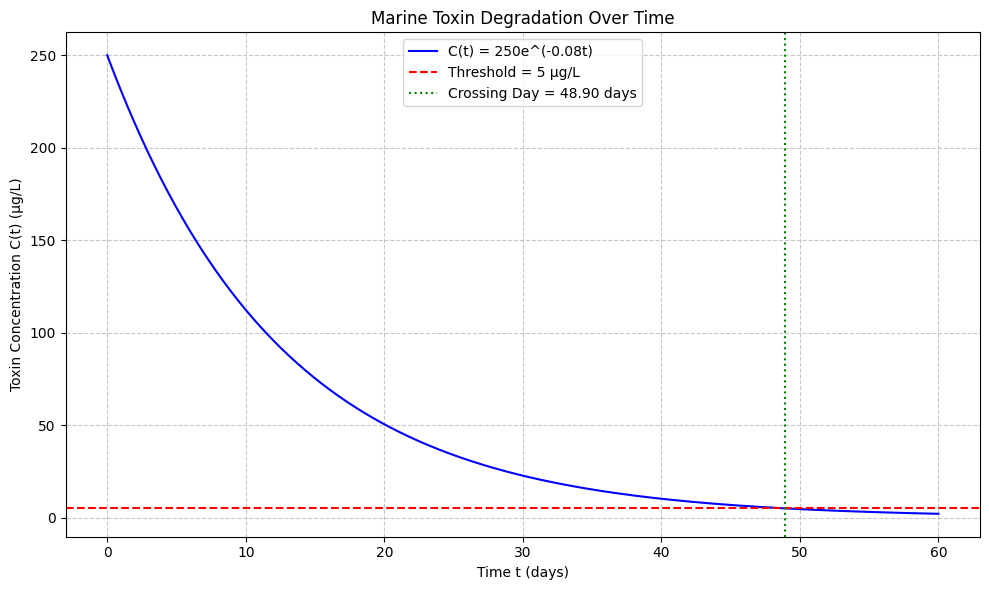

In [ ]:
# Q2c — your code here
import matplotlib.pyplot as plt

# Define the range for t
t_vals_plot = np.linspace(0, 60, 500)

# Calculate C(t) for the plot range
C_vals_plot = C(t_vals_plot)

# Get the crossing day and threshold from previous calculations
crossing_day = t # 't' was calculated in the previous cell
threshold_val = threshold # 'threshold' was defined in the previous cell

fig, ax = plt.subplots(figsize=(10, 6))

# Plot C(t)
ax.plot(t_vals_plot, C_vals_plot, label='C(t) = 250e^(-0.08t)', color='blue')

# Mark the safe-swimming threshold
ax.axhline(threshold_val, color='red', linestyle='--', label=f'Threshold = {threshold_val} μg/L')

# Mark the crossing day
ax.axvline(crossing_day, color='green', linestyle=':', label=f'Crossing Day = {crossing_day:.2f} days')

ax.set_title('Marine Toxin Degradation Over Time')
ax.set_xlabel('Time t (days)')
ax.set_ylabel('Toxin Concentration C(t) (μg/L)')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()
plt.tight_layout()
plt.show()


---
### Q3 — Logistic Fishery (Week 3)

A Carpentaria prawn fishery: $G(S) = 0.5S(1 - S/2000)$.

**(a)** Find the MSY and the stock level at which it occurs. Show the algebraic derivation.
        

**Answer (a):**
G(S) = 0.5S(1-S/2000)
Intrisic growth = g=0.5
Carrying capacity = K=2000t
2000/2=1000t
G(1000)=0.5 x 1000 x (1 1000/2000)
500 x (1-0.5) =
500 x 0.5 =
250
MSY = 250t/yr when stock is at 1000


**(b)** Current stock is 1400 t, harvest is 200 t/yr. Is this sustainable? Justify by computing $G(1400)$.
        

G(S) = 0.5S(1-S/2000)
G(1400) = 0.5 x 1400 x (1-1400/2000)
G(1400) = 700(1-0.7)
G(1400) = 700(0.3)
G(1400) = 210 t/yr

**Justification:** The current harvest of 200 t/yr is sustainable because the calculated growth rate at a stock level of 1400 t is 210 t/yr, which is greater than the harvest rate (G(S) >= H).


**(c)** Find both equilibrium stock levels for $H = 200$ t/yr using the quadratic formula. Identify which is stable and which is unstable.
        

**Answer (c):**

Given the Schaefer model for the Carpentaria prawn fishery:
$G(S) = g S (1 - S/K)$
Where $g = 0.5$ and $K = 2000$. The harvest $H = 200$ t/yr.

To find the equilibrium stock levels, we set $G(S) = H$:
$0.5S(1 - S/2000) = 200$
$0.5S - 0.5S^2/2000 = 200$
$0.5S - 0.00025S^2 = 200$
Rearranging into a quadratic equation $aS^2 + bS + c = 0$:
$-0.00025S^2 + 0.5S - 200 = 0$

Using the quadratic formula $S = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$:
$a = -0.00025$
$b = 0.5$
$c = -200$

Discriminant ($b^2 - 4ac$) = $(0.5)^2 - 4(-0.00025)(-200) = 0.25 - 0.2 = 0.05$

$S = \frac{-0.5 \pm \sqrt{0.05}}{2(-0.00025)}$
$S = \frac{-0.5 \pm 0.2236067977}{-0.0005}$

$S_1 = \frac{-0.5 - 0.2236067977}{-0.0005} = \frac{-0.7236067977}{-0.0005} \approx 1447.21 \text{ t}$
$S_2 = \frac{-0.5 + 0.2236067977}{-0.0005} = \frac{-0.2763932023}{-0.0005} \approx 552.79 \text{ t}$

**Calculated Equilibrium Stock Levels:**
- $S_1 \approx 552.79 \text{ t}$ (Lower equilibrium — unstable collapse threshold)
- $S_2 \approx 1447.21 \text{ t}$ (Upper equilibrium — stable management target)


**(d)** [Written] The manager reduces harvest to 150 t/yr while stock is 1400 t. What happens to the stock over time? Justify from the model.
        


**Answer (d):**
When the harvest is reduced to 150 t/yr while the stock is at 1400 t, the stock is expected to increase over time towards the new stable equilibrium.

Justification:

Current Growth vs. Harvest: At the initial stock level of 1400 t, the population growth rate (G(1400)) is 210 t/yr. With the reduced harvest set at 150 t/yr, the growth (210 t/yr) is greater than the harvest (150 t/yr). This positive difference means that more prawns are being added to the population than are being removed, causing the stock to grow.
New Equilibrium Levels: For a harvest of 150 t/yr, the new equilibrium stock levels are approximately S₁ = 367.54 t (unstable collapse threshold) and S₂ = 1632.46 t (stable management target).
Stock Trajectory: Since the current stock (1400 t) is above the unstable collapse threshold (367.54 t) and below the new stable management target (1632.46 t), the population will naturally increase until it reaches the stable equilibrium of 1632.46 t, assuming the harvest remains at 150 t/yr.
        

```markdown
**Answer (c):**

Given the Schaefer model for the Carpentaria prawn fishery:
$G(S) = g S (1 - S/K)$
Where $g = 0.5$ and $K = 2000$. The harvest $H = 200$ t/yr.

To find the equilibrium stock levels, we set $G(S) = H$:
$0.5S(1 - S/2000) = 200$
$0.5S - 0.5S^2/2000 = 200$
$0.5S - 0.00025S^2 = 200$
Rearranging into a quadratic equation $aS^2 + bS + c = 0$:
$-0.00025S^2 + 0.5S - 200 = 0$

Using the quadratic formula $S = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$:
$a = -0.00025$
$b = 0.5$
$c = -200$

Discriminant ($b^2 - 4ac$) = $(0.5)^2 - 4(-0.00025)(-200) = 0.25 - 0.2 = 0.05$

$S = \frac{-0.5 \pm \sqrt{0.05}}{2(-0.00025)}$
$S = \frac{-0.5 \pm 0.2236067977}{0.0005}$

$S_1 = \frac{-0.5 - 0.2236067977}{-0.0005} = \frac{-0.7236067977}{-0.0005} \approx 1447.21 \text{ t}$
$S_2 = \frac{-0.5 + 0.2236067977}{-0.0005} = \frac{-0.2763932023}{-0.0005} \approx 552.79 \text{ t}$

**Calculated Equilibrium Stock Levels:**
- $S_1 \approx 552.79 \text{ t}$ (Lower equilibrium — unstable collapse threshold)
- $S_2 \approx 1447.21 \text{ t}$ (Upper equilibrium — stable management target)
```

In [ ]:
g_prawn = 0.5
K_prawn = 2000

def G_prawn(S):
    'Annual population growth for prawn fishery (tonnes/year).'
    return g_prawn * S * (1 - S / K_prawn)

S_initial_q3d = 1400 # Current stock
H_q3d = 150        # Reduced harvest

# 1. Calculate the growth rate G(S) for the current stock level (1400 t)
G_at_S_initial_q3d = G_prawn(S_initial_q3d)

# 2. Calculate the new equilibrium stock levels (S₁ and S₂) for the reduced harvest (150 t/yr)
# Schaefer model: G(S) = gS(1 - S/K) = gS - (g/K)S^2
# Set G(S) = H_q3d, so (g/K)S^2 - gS + H_q3d = 0
a_coef_prawn_q3d = g_prawn / K_prawn
b_coef_prawn_q3d = -g_prawn
c_coef_prawn_q3d = H_q3d

disc_prawn_q3d = b_coef_prawn_q3d**2 - 4 * a_coef_prawn_q3d * c_coef_prawn_q3d

# Handle cases where the discriminant might be negative (no real roots)
if disc_prawn_q3d < 0:
    S1_q3d = None
    S2_q3d = None
    print(f"For H = {H_q3d} t/yr, the harvest exceeds MSY, so there are no sustainable equilibrium points.")
else:
    S1_q3d = (-b_coef_prawn_q3d - np.sqrt(disc_prawn_q3d)) / (2 * a_coef_prawn_q3d) # lower (unstable)
    S2_q3d = (-b_coef_prawn_q3d + np.sqrt(disc_prawn_q3d)) / (2 * a_coef_prawn_q3d) # upper (stable)

print(f"Growth rate at S = {S_initial_q3d} t: {G_at_S_initial_q3d:.2f} t/yr")
print(f"New harvest H = {H_q3d} t/yr")
if S1_q3d is not None and S2_q3d is not None:
    print(f"New equilibrium S1 = {S1_q3d:.2f} t (unstable collapse threshold)")
    print(f"New equilibrium S2 = {S2_q3d:.2f} t (stable management target)")
else:
    print("No sustainable equilibrium points found for the new harvest.")


Growth rate at S = 1400 t: 210.00 t/yr
New harvest H = 150 t/yr
New equilibrium S1 = 367.54 t (unstable collapse threshold)
New equilibrium S2 = 1632.46 t (stable management target)
